In [1]:
# import libraries
import cv2
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import os
import re
import scipy.stats as stats
from scipy.signal import find_peaks

In [2]:
# input directory
FI_input_dir = r'./batch_data/separate_motion_modes/Forward_I'
FII_input_dir = r'./batch_data/separate_motion_modes/Forward_II'
B_input_dir = r'./batch_data/separate_motion_modes/Backward'

FI_input_dir = FI_input_dir+r'/full_track/'
FII_input_dir = FII_input_dir+r'/full_track/'
B_input_dir = B_input_dir+r'/full_track/'

In [3]:
# load csv data in dir
FI_velocity_csvs = [f for f in os.listdir(FI_input_dir) if f.endswith('.csv')]
FII_velocity_csvs = [f for f in os.listdir(FII_input_dir) if f.endswith('.csv')]
B_velocity_csvs = [f for f in os.listdir(B_input_dir) if f.endswith('.csv')]
# print number of files
print('Number of FI velocity files: ', len(FI_velocity_csvs))
print('Number of FII velocity files: ', len(FII_velocity_csvs))
print('Number of B velocity files: ', len(B_velocity_csvs))

Number of FI velocity files:  34
Number of FII velocity files:  30
Number of B velocity files:  56


In [4]:
def calculate_circle_center(point_pre, point_current, point_next):
    # see formula here:
    # https://en.wikipedia.org/wiki/Circumcircle#Higher_dimensions

    # convert points to numpy arrays
    p1 = np.array(point_pre)
    p2 = np.array(point_current)
    p3 = np.array(point_next)

    # calculate vectors between the points
    a = p2 - p1
    b = p3 - p1

    # center
    # p0 = C+ ((||a||^2*b)-(||b||^2*a) x (a x b)) / 2||a x b||^2
    term1 = np.linalg.norm(a) ** 2 * b- np.linalg.norm(b) ** 2 * a
    term2 = np.cross(a, b)
    center = p1 + np.cross(term1, term2) / (2 * np.linalg.norm(np.cross(a, b)) ** 2)

    # radius
    # r = ||a|| * ||b|| * ||a-b|| / (2 * ||a x b||)
    radius = np.linalg.norm(a) * np.linalg.norm(b) * np.linalg.norm(a - b) / (2 * np.linalg.norm(np.cross(a, b)))

    # normal vector
    normal_vector = term2/np.linalg.norm(term2)
    return center, radius, normal_vector

def calculate_orientation_vector(angle_xy, angle_z):
    """
    Compute the 3D orientation vector from angle_xy and angle_z.
    
    Parameters:
        angle_xy (float): Orientation in the xy-plane (degrees).
        angle_z (float): Tilt from the xy-plane (degrees).
    
    Returns:
        tuple: (vx, vy, vz) - Unit vector components.
    """
    # Convert degrees to radians
    theta = np.radians(angle_xy)
    phi = np.radians(angle_z)
    
    # Compute the unit vector components
    vx = np.cos(theta) * np.cos(phi)
    vy = np.sin(theta) * np.cos(phi)
    vz = np.sin(phi)
    
    return (vx, vy, vz)

# Function to detect periodicity in x or y
def detect_periodicity(frame_data, signal_data):
    peaks, _ = find_peaks(signal_data, distance=len(signal_data)//5)  # Find peaks to estimate period
    if len(peaks) > 1:
        estimated_period = np.mean(np.diff(peaks))  # Average difference between peaks
        return int(round(estimated_period))
    return len(frame_data)  # If no period is found, return full frame range

# Function to get evenly spaced points in a period
def get_periodic_points(frame_data, x_data, y_data, period_length, current_frame):
    period_start = max(frame_data[0], current_frame - period_length // 2)
    period_end = min(frame_data[-1], current_frame + period_length // 2)

    # Find valid indices within the frame range
    valid_indices = np.where((frame_data >= period_start) & (frame_data <= period_end))[0]

    # If not enough points, return empty
    if len(valid_indices) < 3:
        return []

    # Select three evenly spaced indices
    selected_indices = np.linspace(valid_indices[0], valid_indices[-1], 3, dtype=int)
    
    return [(x_data[i], y_data[i], frame_data[i]) for i in selected_indices]

In [5]:
# DataFrame to store velocity data
FI_velocity_data = pd.DataFrame(columns=[
    'unique_pair', 'frame', 'x', 'y', 'z', 'capsule_radius', 'distance to surface',
    'angle_xy', 'angle_z', 'orientation_vector', 'velocity', 'velocity_vector',
    'angle_between_velocity_and_orientation', 'circular_center', 'circular_radius',
    'normal_vector', 'off_center_distance', 'angle_between_orientation_and_normal_vector', 'period'
])

for csv_index in range(len(FI_velocity_csvs)):
    csv_name = FI_velocity_csvs[csv_index]
    match = re.search(r'pair(\d+)', csv_name)
    unique_pair = int(match.group(1))
    csv_file = FI_input_dir + csv_name
    data = pd.read_csv(csv_file)

    frames = data['frame'].values
    x_vals = data['x'].values
    y_vals = data['y'].values
    z_vals = data['z'].values

    # Estimate period based on x or y movement
    period_length = detect_periodicity(frames, x_vals)

    for row_index in range(1, data.shape[0] - 1):
        current_frame = frames[row_index]

        # Find periodic points
        periodic_points = get_periodic_points(frames, x_vals, y_vals, period_length, current_frame)
        if len(periodic_points) < 3:
            continue  # Skip if not enough points

        # Convert to 3D points with z-values
        points_3d = [(x, y, z_vals[np.searchsorted(frames, frame)]) for x, y, frame in periodic_points]

        # Extract three points for circular center calculation
        point_pre, point_current, point_next = points_3d

        center, radius, normal_vector = calculate_circle_center(point_pre, point_current, point_next)

        capsule_center = np.array([0, 0, 0])
        off_center_distance = np.linalg.norm(center - capsule_center) if radius <= data['capsule_radius'].iloc[row_index] else np.nan

        # Distance to surface
        distance_to_surface = data['capsule_radius'].iloc[row_index] - np.linalg.norm(np.array(point_current) - capsule_center)

        # Orientation vector
        orientation_vector = calculate_orientation_vector(data['angle_xy'].iloc[row_index], data['angle_z'].iloc[row_index])

        # Velocity vector
        velocity_vector = np.array(point_next) - np.array(point_current)

        # Angle between velocity and orientation vector
        angle_velocity_orientation = np.arccos(np.dot(velocity_vector, orientation_vector) / 
                                               (np.linalg.norm(velocity_vector) * np.linalg.norm(orientation_vector)))
        angle_velocity_orientation = np.degrees(angle_velocity_orientation)

        # Angle between orientation and normal vector
        angle_orientation_normal = np.arccos(np.dot(orientation_vector, normal_vector) /
                                             (np.linalg.norm(orientation_vector) * np.linalg.norm(normal_vector)))
        angle_orientation_normal = np.degrees(angle_orientation_normal)

        # Store results
        new_pd = pd.DataFrame({
            'unique_pair': [unique_pair],
            'frame': [current_frame],
            'x': [data['x'].iloc[row_index]],
            'y': [data['y'].iloc[row_index]],
            'z': [data['z'].iloc[row_index]],
            'capsule_radius': [data['capsule_radius'].iloc[row_index]],
            'distance to surface': [distance_to_surface],
            'angle_xy': [data['angle_xy'].iloc[row_index]],
            'angle_z': [data['angle_z'].iloc[row_index]],
            'orientation_vector': [orientation_vector],
            'velocity': [data['velocity'].iloc[row_index]],
            'velocity_vector': [velocity_vector],
            'angle_between_velocity_and_orientation': [angle_velocity_orientation],
            'circular_center': [center],
            'circular_radius': [radius],
            'normal_vector': [normal_vector],
            'off_center_distance': [off_center_distance],
            'angle_between_orientation_and_normal_vector': [angle_orientation_normal],
            'period': [period_length]
        })
        
        FI_velocity_data = pd.concat([FI_velocity_data, new_pd], ignore_index=True)


In [6]:
# DataFrame to store velocity data
FII_velocity_data = pd.DataFrame(columns=[
    'unique_pair', 'frame', 'x', 'y', 'z', 'capsule_radius', 'distance to surface',
    'angle_xy', 'angle_z', 'orientation_vector', 'velocity', 'velocity_vector',
    'angle_between_velocity_and_orientation', 'circular_center', 'circular_radius',
    'normal_vector', 'off_center_distance', 'angle_between_orientation_and_normal_vector', 'period'
])

for csv_index in range(len(FII_velocity_csvs)):
    csv_name = FII_velocity_csvs[csv_index]
    match = re.search(r'pair(\d+)', csv_name)
    unique_pair = int(match.group(1))
    csv_FIIle = FII_input_dir + csv_name
    data = pd.read_csv(csv_FIIle)

    frames = data['frame'].values
    x_vals = data['x'].values
    y_vals = data['y'].values
    z_vals = data['z'].values

    # Estimate period based on x or y movement
    period_length = detect_periodicity(frames, x_vals)

    for row_index in range(1, data.shape[0] - 1):
        current_frame = frames[row_index]

        # FIInd periodic points
        periodic_points = get_periodic_points(frames, x_vals, y_vals, period_length, current_frame)
        if len(periodic_points) < 3:
            continue  # Skip if not enough points

        # Convert to 3D points with z-values
        points_3d = [(x, y, z_vals[np.searchsorted(frames, frame)]) for x, y, frame in periodic_points]

        # Extract three points for circular center calculation
        point_pre, point_current, point_next = points_3d

        center, radius, normal_vector = calculate_circle_center(point_pre, point_current, point_next)

        capsule_center = np.array([0, 0, 0])
        off_center_distance = np.linalg.norm(center - capsule_center) if radius <= data['capsule_radius'].iloc[row_index] else np.nan

        # Distance to surface
        distance_to_surface = data['capsule_radius'].iloc[row_index] - np.linalg.norm(np.array(point_current) - capsule_center)

        # Orientation vector
        orientation_vector = calculate_orientation_vector(data['angle_xy'].iloc[row_index], data['angle_z'].iloc[row_index])

        # Velocity vector
        velocity_vector = np.array(point_next) - np.array(point_current)

        # Angle between velocity and orientation vector
        angle_velocity_orientation = np.arccos(np.dot(velocity_vector, orientation_vector) / 
                                               (np.linalg.norm(velocity_vector) * np.linalg.norm(orientation_vector)))
        angle_velocity_orientation = np.degrees(angle_velocity_orientation)

        # Angle between orientation and normal vector
        angle_orientation_normal = np.arccos(np.dot(orientation_vector, normal_vector) /
                                             (np.linalg.norm(orientation_vector) * np.linalg.norm(normal_vector)))
        angle_orientation_normal = np.degrees(angle_orientation_normal)

        # Store results
        new_pd = pd.DataFrame({
            'unique_pair': [unique_pair],
            'frame': [current_frame],
            'x': [data['x'].iloc[row_index]],
            'y': [data['y'].iloc[row_index]],
            'z': [data['z'].iloc[row_index]],
            'capsule_radius': [data['capsule_radius'].iloc[row_index]],
            'distance to surface': [distance_to_surface],
            'angle_xy': [data['angle_xy'].iloc[row_index]],
            'angle_z': [data['angle_z'].iloc[row_index]],
            'orientation_vector': [orientation_vector],
            'velocity': [data['velocity'].iloc[row_index]],
            'velocity_vector': [velocity_vector],
            'angle_between_velocity_and_orientation': [angle_velocity_orientation],
            'circular_center': [center],
            'circular_radius': [radius],
            'normal_vector': [normal_vector],
            'off_center_distance': [off_center_distance],
            'angle_between_orientation_and_normal_vector': [angle_orientation_normal],
            'period': [period_length]
        })
        
        FII_velocity_data = pd.concat([FII_velocity_data, new_pd], ignore_index=True)


In [7]:
# DataFrame to store velocity data
B_velocity_data = pd.DataFrame(columns=[
    'unique_pair', 'frame', 'x', 'y', 'z', 'capsule_radius', 'distance to surface',
    'angle_xy', 'angle_z', 'orientation_vector', 'velocity', 'velocity_vector',
    'angle_between_velocity_and_orientation', 'circular_center', 'circular_radius',
    'normal_vector', 'off_center_distance', 'angle_between_orientation_and_normal_vector', 'period'
])

for csv_index in range(len(B_velocity_csvs)):
    csv_name = B_velocity_csvs[csv_index]
    match = re.search(r'pair(\d+)', csv_name)
    unique_pair = int(match.group(1))
    csv_Ble = B_input_dir + csv_name
    data = pd.read_csv(csv_Ble)

    frames = data['frame'].values
    x_vals = data['x'].values
    y_vals = data['y'].values
    z_vals = data['z'].values

    # Estimate period based on x or y movement
    period_length = detect_periodicity(frames, x_vals)

    for row_index in range(1, data.shape[0] - 1):
        current_frame = frames[row_index]

        # Bnd periodic points
        periodic_points = get_periodic_points(frames, x_vals, y_vals, period_length, current_frame)
        if len(periodic_points) < 3:
            continue  # Skip if not enough points

        # Convert to 3D points with z-values
        points_3d = [(x, y, z_vals[np.searchsorted(frames, frame)]) for x, y, frame in periodic_points]

        # Extract three points for circular center calculation
        point_pre, point_current, point_next = points_3d

        center, radius, normal_vector = calculate_circle_center(point_pre, point_current, point_next)

        capsule_center = np.array([0, 0, 0])
        off_center_distance = np.linalg.norm(center - capsule_center) if radius <= data['capsule_radius'].iloc[row_index] else np.nan

        # Distance to surface
        distance_to_surface = data['capsule_radius'].iloc[row_index] - np.linalg.norm(np.array(point_current) - capsule_center)

        # Orientation vector
        orientation_vector = calculate_orientation_vector(data['angle_xy'].iloc[row_index], data['angle_z'].iloc[row_index])

        # Velocity vector
        velocity_vector = np.array(point_next) - np.array(point_current)

        # Angle between velocity and orientation vector
        angle_velocity_orientation = np.arccos(np.dot(velocity_vector, orientation_vector) / 
                                               (np.linalg.norm(velocity_vector) * np.linalg.norm(orientation_vector)))
        angle_velocity_orientation = np.degrees(angle_velocity_orientation)

        # Angle between orientation and normal vector
        angle_orientation_normal = np.arccos(np.dot(orientation_vector, normal_vector) /
                                             (np.linalg.norm(orientation_vector) * np.linalg.norm(normal_vector)))
        angle_orientation_normal = np.degrees(angle_orientation_normal)

        # Store results
        new_pd = pd.DataFrame({
            'unique_pair': [unique_pair],
            'frame': [current_frame],
            'x': [data['x'].iloc[row_index]],
            'y': [data['y'].iloc[row_index]],
            'z': [data['z'].iloc[row_index]],
            'capsule_radius': [data['capsule_radius'].iloc[row_index]],
            'distance to surface': [distance_to_surface],
            'angle_xy': [data['angle_xy'].iloc[row_index]],
            'angle_z': [data['angle_z'].iloc[row_index]],
            'orientation_vector': [orientation_vector],
            'velocity': [data['velocity'].iloc[row_index]],
            'velocity_vector': [velocity_vector],
            'angle_between_velocity_and_orientation': [angle_velocity_orientation],
            'circular_center': [center],
            'circular_radius': [radius],
            'normal_vector': [normal_vector],
            'off_center_distance': [off_center_distance],
            'angle_between_orientation_and_normal_vector': [angle_orientation_normal],
            'period': [period_length]
        })
        
        B_velocity_data = pd.concat([B_velocity_data, new_pd], ignore_index=True)


Comparison between motion modes

In [8]:
# prepare summary data for comparison
data_prepare = FI_velocity_data
key_parameters = ['distance to surface', 'velocity', 'angle_between_velocity_and_orientation', 'circular_radius', 'off_center_distance', 'period', 'angle_between_orientation_and_normal_vector', 'angle_xy', 'angle_z']
# get middle 60% for each unique pair
data_prepare_grouped = data_prepare.groupby('unique_pair')
data_prepare_summary_mean = pd.DataFrame(columns=[
    'unique_pair', 'distance to surface', 'velocity', 'angle_between_velocity_and_orientation', 'circular_radius', 'off_center_distance', 'period', 'angle_between_orientation_and_normal_vector', 'angle_xy', 'angle_z'])
data_prepare_summary_median = pd.DataFrame(columns=[
    'unique_pair', 'distance to surface', 'velocity', 'angle_between_velocity_and_orientation', 'circular_radius', 'off_center_distance', 'period', 'angle_between_orientation_and_normal_vector', 'angle_xy', 'angle_z'])
for name, group in data_prepare_grouped:
    # Sort by 'frame' and reset the index
    group = group.sort_values(by='frame').reset_index(drop=True)
    
    # Sort the group by key parameters
    group_sorted = group[key_parameters].sort_values(by=key_parameters, axis=0, ascending=True)
    
    # Get the middle 60% of the sorted data
    start_index = int(group_sorted.shape[0] * 0.2)
    end_index = int(group_sorted.shape[0] * 0.8)
    group_middle = group_sorted.iloc[start_index:end_index, :]

    # # apply ewm to smooth data
    # group_middle = group_middle.ewm(span=30, adjust=False).mean()
    
    # Calculate mean and median of the key parameters for the middle 60%
    group_mean = group_middle.mean()
    group_median = group_middle.median()
    
    # Add the unique pair information to mean and median
    group_mean['unique_pair'] = name
    group_median['unique_pair'] = name

    # Save
    new_pd_mean = pd.DataFrame(group_mean).T
    new_pd_median = pd.DataFrame(group_median).T
    data_prepare_summary_mean = pd.concat([data_prepare_summary_mean, new_pd_mean], ignore_index=True)
    data_prepare_summary_median = pd.concat([data_prepare_summary_median, new_pd_median], ignore_index=True)
# save
FI_summary_mean = data_prepare_summary_mean
FI_summary_median = data_prepare_summary_median

In [9]:
# prepare summary data for comparison
data_prepare = FII_velocity_data
key_parameters = ['distance to surface', 'velocity', 'angle_between_velocity_and_orientation', 'circular_radius', 'off_center_distance', 'period', 'angle_between_orientation_and_normal_vector', 'angle_xy', 'angle_z']
# get middle 60% for each unique pair
data_prepare_grouped = data_prepare.groupby('unique_pair')
data_prepare_summary_mean = pd.DataFrame(columns=[
    'unique_pair', 'distance to surface', 'velocity', 'angle_between_velocity_and_orientation', 'circular_radius', 'off_center_distance', 'period', 'angle_between_orientation_and_normal_vector', 'angle_xy', 'angle_z'])
data_prepare_summary_median = pd.DataFrame(columns=[
    'unique_pair', 'distance to surface', 'velocity', 'angle_between_velocity_and_orientation', 'circular_radius', 'off_center_distance', 'period', 'angle_between_orientation_and_normal_vector', 'angle_xy', 'angle_z'])
for name, group in data_prepare_grouped:
    # Sort by 'frame' and reset the index
    group = group.sort_values(by='frame').reset_index(drop=True)
    
    # Sort the group by key parameters
    group_sorted = group[key_parameters].sort_values(by=key_parameters, axis=0, ascending=True)
    
    # Get the middle 60% of the sorted data
    start_index = int(group_sorted.shape[0] * 0.2)
    end_index = int(group_sorted.shape[0] * 0.8)
    group_middle = group_sorted.iloc[start_index:end_index, :]

    # # apply ewm to smooth data
    # group_middle = group_middle.ewm(span=30, adjust=False).mean()
    
    # Calculate mean and median of the key parameters for the middle 60%
    group_mean = group_middle.mean()
    group_median = group_middle.median()
    
    # Add the unique pair information to mean and median
    group_mean['unique_pair'] = name
    group_median['unique_pair'] = name

    # Save
    new_pd_mean = pd.DataFrame(group_mean).T
    new_pd_median = pd.DataFrame(group_median).T
    data_prepare_summary_mean = pd.concat([data_prepare_summary_mean, new_pd_mean], ignore_index=True)
    data_prepare_summary_median = pd.concat([data_prepare_summary_median, new_pd_median], ignore_index=True)
# save
FII_summary_mean = data_prepare_summary_mean
FII_summary_median = data_prepare_summary_median

In [10]:
# prepare summary data for comparison
data_prepare = B_velocity_data
key_parameters = ['distance to surface', 'velocity', 'angle_between_velocity_and_orientation', 'circular_radius', 'off_center_distance', 'period', 'angle_between_orientation_and_normal_vector', 'angle_xy', 'angle_z']
# get middle 60% for each unique pair
data_prepare_grouped = data_prepare.groupby('unique_pair')
data_prepare_summary_mean = pd.DataFrame(columns=[
    'unique_pair', 'distance to surface', 'velocity', 'angle_between_velocity_and_orientation', 'circular_radius', 'off_center_distance', 'period', 'angle_between_orientation_and_normal_vector', 'angle_xy', 'angle_z'])
data_prepare_summary_median = pd.DataFrame(columns=[
    'unique_pair', 'distance to surface', 'velocity', 'angle_between_velocity_and_orientation', 'circular_radius', 'off_center_distance', 'period', 'angle_between_orientation_and_normal_vector', 'angle_xy', 'angle_z'])
for name, group in data_prepare_grouped:
    # Sort by 'frame' and reset the index
    group = group.sort_values(by='frame').reset_index(drop=True)
    
    # Sort the group by key parameters
    group_sorted = group[key_parameters].sort_values(by=key_parameters, axis=0, ascending=True)
    
    # Get the middle 60% of the sorted data
    start_index = int(group_sorted.shape[0] * 0.2)
    end_index = int(group_sorted.shape[0] * 0.8)
    group_middle = group_sorted.iloc[start_index:end_index, :]

    # # apply ewm to smooth data
    # group_middle = group_middle.ewm(span=30, adjust=False).mean()
    
    # Calculate mean and median of the key parameters for the middle 60%
    group_mean = group_middle.mean()
    group_median = group_middle.median()
    
    # Add the unique pair information to mean and median
    group_mean['unique_pair'] = name
    group_median['unique_pair'] = name

    # Save
    new_pd_mean = pd.DataFrame(group_mean).T
    new_pd_median = pd.DataFrame(group_median).T
    data_prepare_summary_mean = pd.concat([data_prepare_summary_mean, new_pd_mean], ignore_index=True)
    data_prepare_summary_median = pd.concat([data_prepare_summary_median, new_pd_median], ignore_index=True)
# save
B_summary_mean = data_prepare_summary_mean
B_summary_median = data_prepare_summary_median

before - after removing outliers:
FI: 34 - 33
FII: 30 - 29
B: 56 - 56
distance to surface
Pairwise comparisons:
  FI vs. FII p-value: 5.684e-02  Significance: n.s.
  FI vs. B p-value: 9.687e-14  Significance: ***
  FII vs. B p-value: 5.511e-12  Significance: ***

Summary for publication:
Statistical analysis was performed to compare differences in distance to surface.
Normality was assessed using the Shapiro-Wilk test.
Since the data did not follow a normal distribution (p < 0.05), a non-parametric approach was used.
A Kruskal-Wallis test revealed a significant difference across groups (Kruskal-Wallis(2) = 77.558, p = 1.441e-17).
Pairwise comparisons were conducted using:
Mann-Whitney U test with a significance level of α = 0.05.
Pairwise test results:
  FI vs. B: U = 47.000, p = 9.687e-14, ***
  FII vs. B: U = 68.000, p = 5.511e-12, ***
  FI vs. FII: U = 343.000, p = 5.684e-02, n.s.


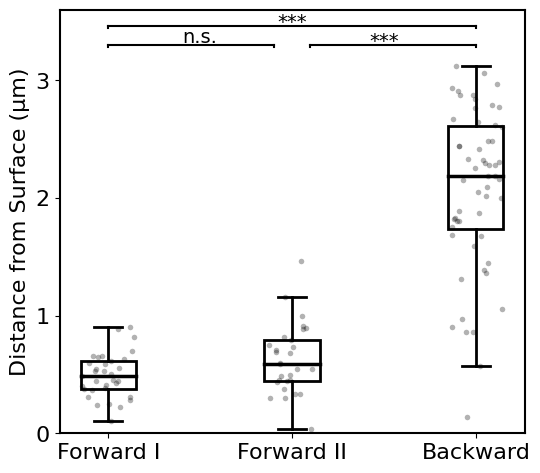

In [11]:
import seaborn as sns
# Define line thickness
thickness_axis = 1.5
thickness_violin = 2
thickness_box = 1.5
thickness_mean = 1.5
thickness_test = 1.5

key_parameter = 'distance to surface'

# Define box plot colors (minimal palette)
# colors = ['#333333', 'dimgray', 'darkgray']
# colors = ['darkgray', 'darkgray', 'darkgray']
colors = ['white', 'white', 'white']

# Create a figure to plot all key parameters
plt.figure(figsize=(6, 5.5))

# Get the data for each dataset
FI_data = FI_summary_mean[key_parameter].dropna()
FII_data = FII_summary_mean[key_parameter].dropna()
B_data = B_summary_mean[key_parameter].dropna()

# Ensure data are numeric arrays
FI_data = np.array(FI_data, dtype=np.float64)
FII_data = np.array(FII_data, dtype=np.float64)
B_data = np.array(B_data, dtype=np.float64)

# sort data
FI_data = np.sort(FI_data)
FII_data = np.sort(FII_data)
B_data = np.sort(B_data)
len_FI = len(FI_data)
len_FII = len(FII_data)
len_B = len(B_data)
# remove outliers: > k*std, < k*std
outlier_k = 3
FI_data = FI_data[(FI_data > np.mean(FI_data) - outlier_k * np.std(FI_data)) & (FI_data < np.mean(FI_data) + outlier_k * np.std(FI_data))]
FII_data = FII_data[(FII_data > np.mean(FII_data) - outlier_k * np.std(FII_data)) & (FII_data < np.mean(FII_data) + outlier_k * np.std(FII_data))]
B_data = B_data[(B_data > np.mean(B_data) - outlier_k * np.std(B_data)) & (B_data < np.mean(B_data) + outlier_k * np.std(B_data))]

print('before - after removing outliers:')
print(f'FI: {len_FI} - {len(FI_data)}')
print(f'FII: {len_FII} - {len(FII_data)}')
print(f'B: {len_B} - {len(B_data)}')
# Perform normality test
normality = all([len(data) > 2 and stats.shapiro(data)[1] > 0.05 for data in [FI_data, FII_data, B_data]])

# Perform overall significance test
if normality:
    overall_stat, overall_p_value = stats.f_oneway(FI_data, FII_data, B_data)  # ANOVA
    test_name = "ANOVA"
else:
    overall_stat, overall_p_value = stats.kruskal(FI_data, FII_data, B_data)  # Kruskal-Wallis
    test_name = "Kruskal-Wallis"

def pairwise_test(data1, data2):
    if normality:
        stat, p_value = stats.ttest_ind(data1, data2, equal_var=False)  # Welch's t-test
        stat_symbol = "t"
    else:
        stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')  # Mann-Whitney U test
        stat_symbol = "U"
    return stat, p_value, stat_symbol

# Compute pairwise statistics and p-values
stat_FI_FII, p_FI_FII, symbol_FI_FII = pairwise_test(FI_data, FII_data)
stat_FI_B, p_FI_B, symbol_FI_B = pairwise_test(FI_data, B_data)
stat_FII_B, p_FII_B, symbol_FII_B = pairwise_test(FII_data, B_data)

# Function to assign significance labels
def significance_label(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "n.s."

# Generate significance labels
sig_FI_FII = significance_label(p_FI_FII)
sig_FI_B = significance_label(p_FI_B)
sig_FII_B = significance_label(p_FII_B)

# # Create box plot
# bp = plt.boxplot([FI_data, FII_data, B_data], vert=True, patch_artist=True, widths=0.5, 
#                     medianprops={'color': 'black', 'linewidth': thickness_mean},
#                     boxprops=dict(linewidth=thickness_box), whiskerprops=dict(linewidth=thickness_axis),
#                     capprops=dict(linewidth=thickness_axis))

# # Set box colors
# for patch, color in zip(bp['boxes'], colors):
#     patch.set_facecolor(color)


# Palette
palette = {
    'Forward I': 'white',
    'Forward II': 'white',
    'Backward': 'white'
}

# Prepare DataFrame
df = pd.DataFrame({
    'value': np.concatenate([FI_data, FII_data, B_data]),
    'group': ['Forward I'] * len(FI_data) + ['Forward II'] * len(FII_data) + ['Backward'] * len(B_data)
})

group_order = ['Forward I', 'Forward II', 'Backward']

# Group the data for boxplot
data_ordered = [df[df['group'] == group]['value'].values for group in group_order]

ax = plt.gca()
bp = ax.boxplot(
    data_ordered,
    positions=range(len(group_order)),
    widths=0.3,
    patch_artist=True,
    boxprops=dict(facecolor='none', edgecolor='k', linewidth=2),
    whiskerprops=dict(color='k', linewidth=2),
    capprops=dict(color='k', linewidth=2),
    medianprops=dict(color='k', linewidth=2.5),
    flierprops=dict(marker='o', markersize=0)
)


# # Violin plot with box inside
# sns.violinplot(data=df, x='group', y='value', palette=palette, order=group_order,
#                inner='box', cut=0.7, linewidth=thickness_violin)


# Strip plot
# fix random seed for reproducibility
np.random.seed(3)
sns.stripplot(data=df, x='group', y='value', order=group_order,
              color='black', size=4, jitter=0.15, alpha=0.3)

# # Overlay median as white circle with black edge
# group_medians = df.groupby('group')['value'].median()
# for i, group in enumerate(group_order):
#     median = group_medians[group]
#     plt.scatter(i, median, color='white', edgecolor='black', s=50, zorder=5)
# Add significance annotations
y_max = np.nanmax([np.nanmax(FI_data), np.nanmax(FII_data), np.nanmax(B_data)])
y_max = y_max + 0.08
y_line = y_max * 1.03
vline_height = y_max * 0.005

# FI vs. FII
plt.plot([0, 0.9], [y_line, y_line], color='black', linewidth=thickness_axis)  # Short line
plt.plot([0, 0], [y_line, y_line - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([0.9, 0.9], [y_line, y_line - vline_height], color='black')  # Adjusted vertical line (right)

# FI vs. B
plt.plot([0, 2], [y_line * 1.05, y_line * 1.05], color='black', linewidth=thickness_axis)  # Short line
plt.plot([0, 0], [y_line * 1.05, y_line * 1.05 - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([2, 2], [y_line * 1.05, y_line * 1.05 - vline_height], color='black')  # Adjusted vertical line (right)

# FII vs. B
plt.plot([1.1, 2], [y_line , y_line ], color='black', linewidth=thickness_axis)  # Short line
plt.plot([1.1, 1.1], [y_line , y_line  - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([2, 2], [y_line , y_line  - vline_height], color='black')  # Adjusted vertical line (right)

# Add significance labels
# -y_max*0.005 if "n.s."
# -y_max*0.01 if "*" or "**" or "***"
plt.text(0.5, y_line * 1 - y_max*0.005, sig_FI_FII, ha='center', va='bottom', fontsize=12, color='black')  # Text color black
plt.text(1, y_line * 1.05 - y_max*0.015, sig_FI_B, ha='center', va='bottom', fontsize=12, color='black')  # Text color black
plt.text(1.5, y_line  - y_max*0.015, sig_FII_B, ha='center', va='bottom', fontsize=12, color='black')  # Text color black

# Set labels
# plt.title(f'{key_parameter}')
print(f'{key_parameter}')
plt.xticks([0, 1, 2], [f'Forward I', f'Forward II', f'Backward'])
# plt.ylabel(f'{key_parameter}')
plt.ylabel('Distance from Surface (µm)')
plt.xlabel('')
# ylim
plt.ylim(0, 3.6)

# Print statistical results
print(f'Pairwise comparisons:')
print(f'  FI vs. FII p-value: {p_FI_FII:.3e}  Significance: {sig_FI_FII}')
print(f'  FI vs. B p-value: {p_FI_B:.3e}  Significance: {sig_FI_B}')
print(f'  FII vs. B p-value: {p_FII_B:.3e}  Significance: {sig_FII_B}')

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=16)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=16)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=16)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
ax.locator_params(axis='y', nbins=6)
ax.locator_params(axis='x', nbins=6)

# Set x tick label font
ax.tick_params(axis='x', which='major', labelsize=16)

# Print statistical summary for publication
print("\nSummary for publication:")
print(f"Statistical analysis was performed to compare differences in {key_parameter}.")
print("Normality was assessed using the Shapiro-Wilk test.")
if normality:
    print(f"Since the data followed a normal distribution (p > 0.05), ANOVA was used.")
    print(f"A {test_name} test revealed a significant difference across groups (F(2, N) = {overall_stat:.3f}, p = {overall_p_value:.3e}).")
else:
    print(f"Since the data did not follow a normal distribution (p < 0.05), a non-parametric approach was used.")
    print(f"A {test_name} test revealed a significant difference across groups ({test_name}(2) = {overall_stat:.3f}, p = {overall_p_value:.3e}).")

print("Pairwise comparisons were conducted using:")
if normality:
    print("Welch’s t-test with a significance level of α = 0.05.")
else:
    print("Mann-Whitney U test with a significance level of α = 0.05.")

print(f"Pairwise test results:")
print(f"  FI vs. B: {symbol_FI_B} = {stat_FI_B:.3f}, p = {p_FI_B:.3e}, {sig_FI_B}")
print(f"  FII vs. B: {symbol_FII_B} = {stat_FII_B:.3f}, p = {p_FII_B:.3e}, {sig_FII_B}")
print(f"  FI vs. FII: {symbol_FI_FII} = {stat_FI_FII:.3f}, p = {p_FI_FII:.3e}, {sig_FI_FII}")

# plt.ylim(0,4.5)
# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('{}-box+strip.png'.format(key_parameter), format='png', dpi=900, transparent=True, bbox_inches='tight')



before - after removing outliers:
FI: 34 - 34
FII: 30 - 30
B: 56 - 56
velocity
Pairwise comparisons:
  FI vs. FII p-value: 4.690e-05  Significance: ***
  FI vs. B p-value: 9.662e-03  Significance: **
  FII vs. B p-value: 3.107e-13  Significance: ***

Summary for publication:
Statistical analysis was performed to compare differences in velocity.
Normality was assessed using the Shapiro-Wilk test.
Since the data followed a normal distribution (p > 0.05), ANOVA was used.
A ANOVA test revealed a significant difference across groups (F(2, N) = 34.950, p = 1.258e-12).
Pairwise comparisons were conducted using:
Welch’s t-test with a significance level of α = 0.05.
Pairwise test results:
  FI vs. B: t = 2.693, p = 9.662e-03, **
  FII vs. B: t = 9.535, p = 3.107e-13, ***
  FI vs. FII: t = -4.395, p = 4.690e-05, ***


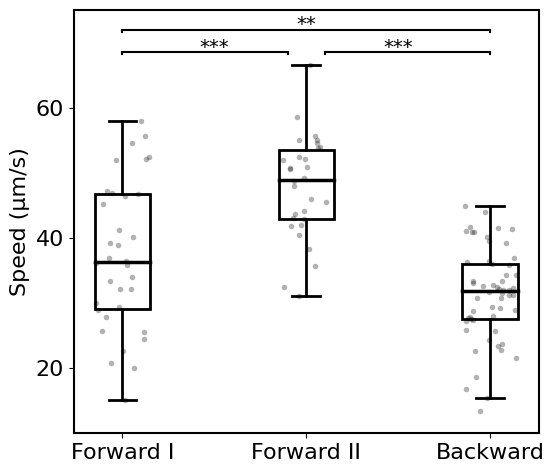

In [12]:
import seaborn as sns
# Define line thickness
thickness_axis = 1.5
thickness_violin = 2.5
thickness_box = 1.5
thickness_mean = 1.5
thickness_test = 1.5

key_parameter = 'velocity'

# Define box plot colors (minimal palette)
# colors = ['#333333', 'dimgray', 'darkgray']
# colors = ['darkgray', 'darkgray', 'darkgray']
colors = ['white', 'white', 'white']

# Create a figure to plot all key parameters
plt.figure(figsize=(6, 5.5))

# Get the data for each dataset
FI_data = FI_summary_mean[key_parameter].dropna()
FII_data = FII_summary_mean[key_parameter].dropna()
B_data = B_summary_mean[key_parameter].dropna()

# Ensure data are numeric arrays
FI_data = np.array(FI_data, dtype=np.float64)
FII_data = np.array(FII_data, dtype=np.float64)
B_data = np.array(B_data, dtype=np.float64)

# sort data
FI_data = np.sort(FI_data)
FII_data = np.sort(FII_data)
B_data = np.sort(B_data)
len_FI = len(FI_data)
len_FII = len(FII_data)
len_B = len(B_data)
# remove outliers: > k*std, < k*std
outlier_k = 3
FI_data = FI_data[(FI_data > np.mean(FI_data) - outlier_k * np.std(FI_data)) & (FI_data < np.mean(FI_data) + outlier_k * np.std(FI_data))]
FII_data = FII_data[(FII_data > np.mean(FII_data) - outlier_k * np.std(FII_data)) & (FII_data < np.mean(FII_data) + outlier_k * np.std(FII_data))]
B_data = B_data[(B_data > np.mean(B_data) - outlier_k * np.std(B_data)) & (B_data < np.mean(B_data) + outlier_k * np.std(B_data))]

print('before - after removing outliers:')
print(f'FI: {len_FI} - {len(FI_data)}')
print(f'FII: {len_FII} - {len(FII_data)}')
print(f'B: {len_B} - {len(B_data)}')
# Perform normality test
normality = all([len(data) > 2 and stats.shapiro(data)[1] > 0.05 for data in [FI_data, FII_data, B_data]])

# Perform overall significance test
if normality:
    overall_stat, overall_p_value = stats.f_oneway(FI_data, FII_data, B_data)  # ANOVA
    test_name = "ANOVA"
else:
    overall_stat, overall_p_value = stats.kruskal(FI_data, FII_data, B_data)  # Kruskal-Wallis
    test_name = "Kruskal-Wallis"

def pairwise_test(data1, data2):
    if normality:
        stat, p_value = stats.ttest_ind(data1, data2, equal_var=False)  # Welch's t-test
        stat_symbol = "t"
    else:
        stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')  # Mann-Whitney U test
        stat_symbol = "U"
    return stat, p_value, stat_symbol

# Compute pairwise statistics and p-values
stat_FI_FII, p_FI_FII, symbol_FI_FII = pairwise_test(FI_data, FII_data)
stat_FI_B, p_FI_B, symbol_FI_B = pairwise_test(FI_data, B_data)
stat_FII_B, p_FII_B, symbol_FII_B = pairwise_test(FII_data, B_data)

# Function to assign significance labels
def significance_label(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "n.s."

# Generate significance labels
sig_FI_FII = significance_label(p_FI_FII)
sig_FI_B = significance_label(p_FI_B)
sig_FII_B = significance_label(p_FII_B)

# # Create box plot
# bp = plt.boxplot([FI_data, FII_data, B_data], vert=True, patch_artist=True, widths=0.5, 
#                     medianprops={'color': 'black', 'linewidth': thickness_mean},
#                     boxprops=dict(linewidth=thickness_box), whiskerprops=dict(linewidth=thickness_axis),
#                     capprops=dict(linewidth=thickness_axis))

# # Set box colors
# for patch, color in zip(bp['boxes'], colors):
#     patch.set_facecolor(color)


# Palette
palette = {
    'Forward I': 'white',
    'Forward II': 'white',
    'Backward': 'white'
}

# Prepare DataFrame
df = pd.DataFrame({
    'value': np.concatenate([FI_data, FII_data, B_data]),
    'group': ['Forward I'] * len(FI_data) + ['Forward II'] * len(FII_data) + ['Backward'] * len(B_data)
})

group_order = ['Forward I', 'Forward II', 'Backward']

# Group the data for boxplot
data_ordered = [df[df['group'] == group]['value'].values for group in group_order]

ax = plt.gca()
bp = ax.boxplot(
    data_ordered,
    positions=range(len(group_order)),
    widths=0.3,
    patch_artist=True,
    boxprops=dict(facecolor='none', edgecolor='k', linewidth=2),
    whiskerprops=dict(color='k', linewidth=2),
    capprops=dict(color='k', linewidth=2),
    medianprops=dict(color='k', linewidth=2.5),
    flierprops=dict(marker='o', markersize=0)
)


# # Violin plot with box inside
# sns.violinplot(data=df, x='group', y='value', palette=palette, order=group_order,
#                inner='box', cut=0.7, linewidth=thickness_violin)


# Strip plot
# fix random seed for reproducibility
np.random.seed(3)
sns.stripplot(data=df, x='group', y='value', order=group_order,
              color='black', size=4, jitter=0.15, alpha=0.3)

# # Overlay median as white circle with black edge
# group_medians = df.groupby('group')['value'].median()
# for i, group in enumerate(group_order):
#     median = group_medians[group]
#     plt.scatter(i, median, color='white', edgecolor='black', s=50, zorder=5)
# Add significance annotations
y_max = np.nanmax([np.nanmax(FI_data), np.nanmax(FII_data), np.nanmax(B_data)])
y_max = y_max + 0
y_line = y_max * 1.03
vline_height = y_max * 0.005

# FI vs. FII
plt.plot([0, 0.9], [y_line, y_line], color='black', linewidth=thickness_axis)  # Short line
plt.plot([0, 0], [y_line, y_line - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([0.9, 0.9], [y_line, y_line - vline_height], color='black')  # Adjusted vertical line (right)

# FI vs. B
plt.plot([0, 2], [y_line * 1.05, y_line * 1.05], color='black', linewidth=thickness_axis)  # Short line
plt.plot([0, 0], [y_line * 1.05, y_line * 1.05 - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([2, 2], [y_line * 1.05, y_line * 1.05 - vline_height], color='black')  # Adjusted vertical line (right)

# FII vs. B
plt.plot([1.1, 2], [y_line , y_line ], color='black', linewidth=thickness_axis)  # Short line
plt.plot([1.1, 1.1], [y_line , y_line  - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([2, 2], [y_line , y_line  - vline_height], color='black')  # Adjusted vertical line (right)

# Add significance labels
# -y_max*0.005 if "n.s."
# -y_max*0.01 if "*" or "**" or "***"
plt.text(0.5, y_line * 1 - y_max*0.01, sig_FI_FII, ha='center', va='bottom', fontsize=12, color='black')  # Text color black
plt.text(1, y_line * 1.05 - y_max*0.01, sig_FI_B, ha='center', va='bottom', fontsize=12, color='black')  # Text color black
plt.text(1.5, y_line  - y_max*0.01, sig_FII_B, ha='center', va='bottom', fontsize=12, color='black')  # Text color black

# Set labels
# plt.title(f'{key_parameter}')
print(f'{key_parameter}')
plt.xticks([0, 1, 2], [f'Forward I', f'Forward II', f'Backward'])
# plt.ylabel(f'{key_parameter}')
plt.ylabel('Speed (µm/s)')
plt.xlabel('')
# ylim
plt.ylim(10, 75)

# Print statistical results
print(f'Pairwise comparisons:')
print(f'  FI vs. FII p-value: {p_FI_FII:.3e}  Significance: {sig_FI_FII}')
print(f'  FI vs. B p-value: {p_FI_B:.3e}  Significance: {sig_FI_B}')
print(f'  FII vs. B p-value: {p_FII_B:.3e}  Significance: {sig_FII_B}')

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=16)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=16)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=16)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
ax.locator_params(axis='y', nbins=6)
ax.locator_params(axis='x', nbins=6)

# Set x tick label font
ax.tick_params(axis='x', which='major', labelsize=16)

# Print statistical summary for publication
print("\nSummary for publication:")
print(f"Statistical analysis was performed to compare differences in {key_parameter}.")
print("Normality was assessed using the Shapiro-Wilk test.")
if normality:
    print(f"Since the data followed a normal distribution (p > 0.05), ANOVA was used.")
    print(f"A {test_name} test revealed a significant difference across groups (F(2, N) = {overall_stat:.3f}, p = {overall_p_value:.3e}).")
else:
    print(f"Since the data did not follow a normal distribution (p < 0.05), a non-parametric approach was used.")
    print(f"A {test_name} test revealed a significant difference across groups ({test_name}(2) = {overall_stat:.3f}, p = {overall_p_value:.3e}).")

print("Pairwise comparisons were conducted using:")
if normality:
    print("Welch’s t-test with a significance level of α = 0.05.")
else:
    print("Mann-Whitney U test with a significance level of α = 0.05.")

print(f"Pairwise test results:")
print(f"  FI vs. B: {symbol_FI_B} = {stat_FI_B:.3f}, p = {p_FI_B:.3e}, {sig_FI_B}")
print(f"  FII vs. B: {symbol_FII_B} = {stat_FII_B:.3f}, p = {p_FII_B:.3e}, {sig_FII_B}")
print(f"  FI vs. FII: {symbol_FI_FII} = {stat_FI_FII:.3f}, p = {p_FI_FII:.3e}, {sig_FI_FII}")


# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('{}-box+strip.png'.format(key_parameter), format='png', dpi=900, transparent=True, bbox_inches='tight')



before - after removing outliers:
FI: 34 - 32
FII: 30 - 22
B: 56 - 47
circular_radius
Pairwise comparisons:
  FI vs. FII p-value: 2.058e-08  Significance: ***
  FI vs. B p-value: 6.143e-14  Significance: ***
  FII vs. B p-value: 5.209e-10  Significance: ***

Summary for publication:
Statistical analysis was performed to compare differences in circular_radius.
Normality was assessed using the Shapiro-Wilk test.
Since the data did not follow a normal distribution (p < 0.05), a non-parametric approach was used.
A Kruskal-Wallis test revealed a significant difference across groups (Kruskal-Wallis(2) = 80.977, p = 2.606e-18).
Pairwise comparisons were conducted using:
Mann-Whitney U test with a significance level of α = 0.05.
Pairwise test results:
  FI vs. B: U = 1504.000, p = 6.143e-14, ***
  FII vs. B: U = 1000.000, p = 5.209e-10, ***
  FI vs. FII: U = 671.000, p = 2.058e-08, ***


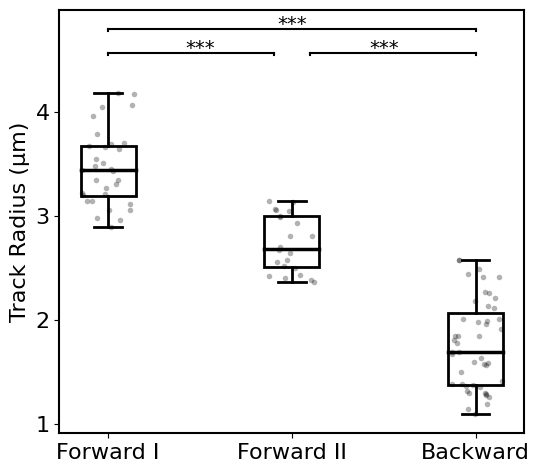

In [13]:
import seaborn as sns
# Define line thickness
thickness_axis = 1.5
thickness_violin = 2.5
thickness_box = 1.5
thickness_mean = 1.5
thickness_test = 1.5

key_parameter = 'circular_radius'

# Define box plot colors (minimal palette)
# colors = ['#333333', 'dimgray', 'darkgray']
# colors = ['darkgray', 'darkgray', 'darkgray']
colors = ['white', 'white', 'white']

# Create a figure to plot all key parameters
plt.figure(figsize=(6, 5.5))

# Get the data for each dataset
FI_data = FI_summary_mean[key_parameter].dropna()
FII_data = FII_summary_mean[key_parameter].dropna()
B_data = B_summary_mean[key_parameter].dropna()

# Ensure data are numeric arrays
FI_data = np.array(FI_data, dtype=np.float64)
FII_data = np.array(FII_data, dtype=np.float64)
B_data = np.array(B_data, dtype=np.float64)

# sort data
FI_data = np.sort(FI_data)
FII_data = np.sort(FII_data)
B_data = np.sort(B_data)
len_FI = len(FI_data)
len_FII = len(FII_data)
len_B = len(B_data)
# remove outliers: > k*std, < k*std
outlier_k = 1.25
FI_data = FI_data[(FI_data > np.mean(FI_data) - outlier_k * np.std(FI_data)) & (FI_data < np.mean(FI_data) + outlier_k * np.std(FI_data))]
FII_data = FII_data[(FII_data > np.mean(FII_data) - outlier_k * np.std(FII_data)) & (FII_data < np.mean(FII_data) + outlier_k * np.std(FII_data))]
B_data = B_data[(B_data > np.mean(B_data) - outlier_k * np.std(B_data)) & (B_data < np.mean(B_data) + outlier_k * np.std(B_data))]

print('before - after removing outliers:')
print(f'FI: {len_FI} - {len(FI_data)}')
print(f'FII: {len_FII} - {len(FII_data)}')
print(f'B: {len_B} - {len(B_data)}')
# Perform normality test
normality = all([len(data) > 2 and stats.shapiro(data)[1] > 0.05 for data in [FI_data, FII_data, B_data]])

# Perform overall significance test
if normality:
    overall_stat, overall_p_value = stats.f_oneway(FI_data, FII_data, B_data)  # ANOVA
    test_name = "ANOVA"
else:
    overall_stat, overall_p_value = stats.kruskal(FI_data, FII_data, B_data)  # Kruskal-Wallis
    test_name = "Kruskal-Wallis"

def pairwise_test(data1, data2):
    if normality:
        stat, p_value = stats.ttest_ind(data1, data2, equal_var=False)  # Welch's t-test
        stat_symbol = "t"
    else:
        stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')  # Mann-Whitney U test
        stat_symbol = "U"
    return stat, p_value, stat_symbol

# Compute pairwise statistics and p-values
stat_FI_FII, p_FI_FII, symbol_FI_FII = pairwise_test(FI_data, FII_data)
stat_FI_B, p_FI_B, symbol_FI_B = pairwise_test(FI_data, B_data)
stat_FII_B, p_FII_B, symbol_FII_B = pairwise_test(FII_data, B_data)

# Function to assign significance labels
def significance_label(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "n.s."

# Generate significance labels
sig_FI_FII = significance_label(p_FI_FII)
sig_FI_B = significance_label(p_FI_B)
sig_FII_B = significance_label(p_FII_B)

# # Create box plot
# bp = plt.boxplot([FI_data, FII_data, B_data], vert=True, patch_artist=True, widths=0.5, 
#                     medianprops={'color': 'black', 'linewidth': thickness_mean},
#                     boxprops=dict(linewidth=thickness_box), whiskerprops=dict(linewidth=thickness_axis),
#                     capprops=dict(linewidth=thickness_axis))

# # Set box colors
# for patch, color in zip(bp['boxes'], colors):
#     patch.set_facecolor(color)


# Palette
palette = {
    'Forward I': 'white',
    'Forward II': 'white',
    'Backward': 'white'
}

# Prepare DataFrame
df = pd.DataFrame({
    'value': np.concatenate([FI_data, FII_data, B_data]),
    'group': ['Forward I'] * len(FI_data) + ['Forward II'] * len(FII_data) + ['Backward'] * len(B_data)
})

group_order = ['Forward I', 'Forward II', 'Backward']

# Group the data for boxplot
data_ordered = [df[df['group'] == group]['value'].values for group in group_order]

ax = plt.gca()
bp = ax.boxplot(
    data_ordered,
    positions=range(len(group_order)),
    widths=0.3,
    patch_artist=True,
    boxprops=dict(facecolor='none', edgecolor='k', linewidth=2),
    whiskerprops=dict(color='k', linewidth=2),
    capprops=dict(color='k', linewidth=2),
    medianprops=dict(color='k', linewidth=2.5),
    flierprops=dict(marker='o', markersize=0)
)


# # Violin plot with box inside
# sns.violinplot(data=df, x='group', y='value', palette=palette, order=group_order,
#                inner='box', cut=0.7, linewidth=thickness_violin)


# Strip plot
# fix random seed for reproducibility
np.random.seed(3)
sns.stripplot(data=df, x='group', y='value', order=group_order,
              color='black', size=4, jitter=0.15, alpha=0.3)

# # Overlay median as white circle with black edge
# group_medians = df.groupby('group')['value'].median()
# for i, group in enumerate(group_order):
#     median = group_medians[group]
#     plt.scatter(i, median, color='white', edgecolor='black', s=50, zorder=5)

# Add significance annotations
y_max = np.nanmax([np.nanmax(FI_data), np.nanmax(FII_data), np.nanmax(B_data)])
y_max = y_max + 0.25
y_line = y_max * 1.03
vline_height = y_max * 0.005

# FI vs. FII
plt.plot([0, 0.9], [y_line, y_line], color='black', linewidth=thickness_axis)  # Short line
plt.plot([0, 0], [y_line, y_line - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([0.9, 0.9], [y_line, y_line - vline_height], color='black')  # Adjusted vertical line (right)

# FI vs. B
plt.plot([0, 2], [y_line * 1.05, y_line * 1.05], color='black', linewidth=thickness_axis)  # Short line
plt.plot([0, 0], [y_line * 1.05, y_line * 1.05 - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([2, 2], [y_line * 1.05, y_line * 1.05 - vline_height], color='black')  # Adjusted vertical line (right)

# FII vs. B
plt.plot([1.1, 2], [y_line , y_line ], color='black', linewidth=thickness_axis)  # Short line
plt.plot([1.1, 1.1], [y_line , y_line  - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([2, 2], [y_line , y_line  - vline_height], color='black')  # Adjusted vertical line (right)

# Add significance labels
# -y_max*0.005 if "n.s."
# -y_max*0.01 if "*" or "**" or "***"
plt.text(0.5, y_line * 1 - y_max*0.01, sig_FI_FII, ha='center', va='bottom', fontsize=12, color='black')  # Text color black
plt.text(1, y_line * 1.05 - y_max*0.01, sig_FI_B, ha='center', va='bottom', fontsize=12, color='black')  # Text color black
plt.text(1.5, y_line  - y_max*0.01, sig_FII_B, ha='center', va='bottom', fontsize=12, color='black')  # Text color black

# Set labels
# plt.title(f'{key_parameter}')
print(f'{key_parameter}')
plt.xticks([0, 1, 2], [f'Forward I', f'Forward II', f'Backward'])
# plt.ylabel(f'{key_parameter}')
plt.ylabel('Track Radius (µm)')
plt.xlabel('')

# Print statistical results
print(f'Pairwise comparisons:')
print(f'  FI vs. FII p-value: {p_FI_FII:.3e}  Significance: {sig_FI_FII}')
print(f'  FI vs. B p-value: {p_FI_B:.3e}  Significance: {sig_FI_B}')
print(f'  FII vs. B p-value: {p_FII_B:.3e}  Significance: {sig_FII_B}')

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=16)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=16)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=16)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
ax.locator_params(axis='y', nbins=6)
ax.locator_params(axis='x', nbins=6)
# set y ticks
ax.set_yticks([1, 2, 3, 4])

# Set x tick label font
ax.tick_params(axis='x', which='major', labelsize=16)

# Print statistical summary for publication
print("\nSummary for publication:")
print(f"Statistical analysis was performed to compare differences in {key_parameter}.")
print("Normality was assessed using the Shapiro-Wilk test.")
if normality:
    print(f"Since the data followed a normal distribution (p > 0.05), ANOVA was used.")
    print(f"A {test_name} test revealed a significant difference across groups (F(2, N) = {overall_stat:.3f}, p = {overall_p_value:.3e}).")
else:
    print(f"Since the data did not follow a normal distribution (p < 0.05), a non-parametric approach was used.")
    print(f"A {test_name} test revealed a significant difference across groups ({test_name}(2) = {overall_stat:.3f}, p = {overall_p_value:.3e}).")

print("Pairwise comparisons were conducted using:")
if normality:
    print("Welch’s t-test with a significance level of α = 0.05.")
else:
    print("Mann-Whitney U test with a significance level of α = 0.05.")

print(f"Pairwise test results:")
print(f"  FI vs. B: {symbol_FI_B} = {stat_FI_B:.3f}, p = {p_FI_B:.3e}, {sig_FI_B}")
print(f"  FII vs. B: {symbol_FII_B} = {stat_FII_B:.3f}, p = {p_FII_B:.3e}, {sig_FII_B}")
print(f"  FI vs. FII: {symbol_FI_FII} = {stat_FI_FII:.3f}, p = {p_FI_FII:.3e}, {sig_FI_FII}")


# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('{}-box+strip.png'.format(key_parameter), format='png', dpi=900, transparent=True, bbox_inches='tight')



before - after removing outliers:
FI: 34 - 34
FII: 30 - 30
B: 56 - 56
off_center_distance
Pairwise comparisons:
  FI vs. FII p-value: 3.099e-09  Significance: ***
  FI vs. B p-value: 3.942e-02  Significance: *
  FII vs. B p-value: 1.549e-09  Significance: ***

Summary for publication:
Statistical analysis was performed to compare differences in off_center_distance.
Normality was assessed using the Shapiro-Wilk test.
Since the data did not follow a normal distribution (p < 0.05), a non-parametric approach was used.
A Kruskal-Wallis test revealed a significant difference across groups (Kruskal-Wallis(2) = 47.950, p = 3.871e-11).
Pairwise comparisons were conducted using:
Mann-Whitney U test with a significance level of α = 0.05.
Pairwise test results:
  FI vs. B: U = 704.000, p = 3.942e-02, *
  FII vs. B: U = 1507.000, p = 1.549e-09, ***
  FI vs. FII: U = 69.000, p = 3.099e-09, ***


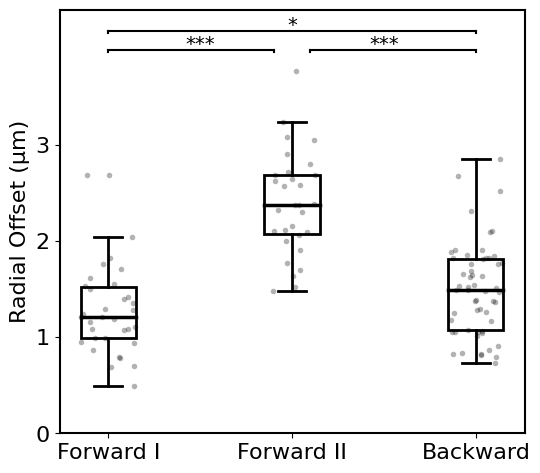

In [14]:
import seaborn as sns
# Define line thickness
thickness_axis = 1.5
thickness_violin = 2.5
thickness_box = 1.5
thickness_mean = 1.5
thickness_test = 1.5

key_parameter = 'off_center_distance'

# Define box plot colors (minimal palette)
# colors = ['#333333', 'dimgray', 'darkgray']
# colors = ['darkgray', 'darkgray', 'darkgray']
colors = ['white', 'white', 'white']

# Create a figure to plot all key parameters
plt.figure(figsize=(6, 5.5))

# Get the data for each dataset
FI_data = FI_summary_mean[key_parameter].dropna()
FII_data = FII_summary_mean[key_parameter].dropna()
B_data = B_summary_mean[key_parameter].dropna()

# Ensure data are numeric arrays
FI_data = np.array(FI_data, dtype=np.float64)
FII_data = np.array(FII_data, dtype=np.float64)
B_data = np.array(B_data, dtype=np.float64)

# sort data
FI_data = np.sort(FI_data)
FII_data = np.sort(FII_data)
B_data = np.sort(B_data)
len_FI = len(FI_data)
len_FII = len(FII_data)
len_B = len(B_data)
# remove outliers: > k*std, < k*std
outlier_k = 3
FI_data = FI_data[(FI_data > np.mean(FI_data) - outlier_k * np.std(FI_data)) & (FI_data < np.mean(FI_data) + outlier_k * np.std(FI_data))]
FII_data = FII_data[(FII_data > np.mean(FII_data) - outlier_k * np.std(FII_data)) & (FII_data < np.mean(FII_data) + outlier_k * np.std(FII_data))]
B_data = B_data[(B_data > np.mean(B_data) - outlier_k * np.std(B_data)) & (B_data < np.mean(B_data) + outlier_k * np.std(B_data))]

print('before - after removing outliers:')
print(f'FI: {len_FI} - {len(FI_data)}')
print(f'FII: {len_FII} - {len(FII_data)}')
print(f'B: {len_B} - {len(B_data)}')
# Perform normality test
normality = all([len(data) > 2 and stats.shapiro(data)[1] > 0.05 for data in [FI_data, FII_data, B_data]])

# Perform overall significance test
if normality:
    overall_stat, overall_p_value = stats.f_oneway(FI_data, FII_data, B_data)  # ANOVA
    test_name = "ANOVA"
else:
    overall_stat, overall_p_value = stats.kruskal(FI_data, FII_data, B_data)  # Kruskal-Wallis
    test_name = "Kruskal-Wallis"

def pairwise_test(data1, data2):
    if normality:
        stat, p_value = stats.ttest_ind(data1, data2, equal_var=False)  # Welch's t-test
        stat_symbol = "t"
    else:
        stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')  # Mann-Whitney U test
        stat_symbol = "U"
    return stat, p_value, stat_symbol

# Compute pairwise statistics and p-values
stat_FI_FII, p_FI_FII, symbol_FI_FII = pairwise_test(FI_data, FII_data)
stat_FI_B, p_FI_B, symbol_FI_B = pairwise_test(FI_data, B_data)
stat_FII_B, p_FII_B, symbol_FII_B = pairwise_test(FII_data, B_data)

# Function to assign significance labels
def significance_label(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "n.s."

# Generate significance labels
sig_FI_FII = significance_label(p_FI_FII)
sig_FI_B = significance_label(p_FI_B)
sig_FII_B = significance_label(p_FII_B)

# # Create box plot
# bp = plt.boxplot([FI_data, FII_data, B_data], vert=True, patch_artist=True, widths=0.5, 
#                     medianprops={'color': 'black', 'linewidth': thickness_mean},
#                     boxprops=dict(linewidth=thickness_box), whiskerprops=dict(linewidth=thickness_axis),
#                     capprops=dict(linewidth=thickness_axis))

# # Set box colors
# for patch, color in zip(bp['boxes'], colors):
#     patch.set_facecolor(color)


# Palette
palette = {
    'Forward I': 'white',
    'Forward II': 'white',
    'Backward': 'white'
}

# Prepare DataFrame
df = pd.DataFrame({
    'value': np.concatenate([FI_data, FII_data, B_data]),
    'group': ['Forward I'] * len(FI_data) + ['Forward II'] * len(FII_data) + ['Backward'] * len(B_data)
})

group_order = ['Forward I', 'Forward II', 'Backward']

# Group the data for boxplot
data_ordered = [df[df['group'] == group]['value'].values for group in group_order]

ax = plt.gca()
bp = ax.boxplot(
    data_ordered,
    positions=range(len(group_order)),
    widths=0.3,
    patch_artist=True,
    boxprops=dict(facecolor='none', edgecolor='k', linewidth=2),
    whiskerprops=dict(color='k', linewidth=2),
    capprops=dict(color='k', linewidth=2),
    medianprops=dict(color='k', linewidth=2.5),
    flierprops=dict(marker='o', markersize=0)
)

# bp = ax.boxplot(
#     data_ordered,
#     positions=range(len(group_order)),
#     widths=0.3,
#     patch_artist=True,
#     boxprops=dict(facecolor='none', edgecolor='k', linewidth=2, alpha=0.4),
#     whiskerprops=dict(color='k', linewidth=2, alpha = 0.4),
#     capprops=dict(color='k', linewidth=2, alpha = 0.4),
#     medianprops=dict(color='k', linewidth=2.5, alpha=0),
#     flierprops=dict(marker='o', markersize=0)
# )


# # Violin plot with box inside
# sns.violinplot(data=df, x='group', y='value', palette=palette, order=group_order,
#                inner='box', cut=0.7, linewidth=thickness_violin)


# Strip plot
# fix random seed for reproducibility
np.random.seed(4)
sns.stripplot(data=df, x='group', y='value', order=group_order,
              color='black', size=4, jitter=0.15, alpha=0.3)

# # Overlay median as white circle with black edge
# group_medians = df.groupby('group')['value'].median()
# for i, group in enumerate(group_order):
#     median = group_medians[group]
#     plt.scatter(i, median, color='white', edgecolor='black', s=50, zorder=5)

# Add significance annotations
y_max = np.nanmax([np.nanmax(FI_data), np.nanmax(FII_data), np.nanmax(B_data)])
y_max = y_max + 0.1
y_line = y_max * 1.03
vline_height = y_max * 0.005

# FI vs. FII
plt.plot([0, 0.9], [y_line, y_line], color='black', linewidth=thickness_axis)  # Short line
plt.plot([0, 0], [y_line, y_line - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([0.9, 0.9], [y_line, y_line - vline_height], color='black')  # Adjusted vertical line (right)

# FI vs. B
plt.plot([0, 2], [y_line * 1.05, y_line * 1.05], color='black', linewidth=thickness_axis)  # Short line
plt.plot([0, 0], [y_line * 1.05, y_line * 1.05 - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([2, 2], [y_line * 1.05, y_line * 1.05 - vline_height], color='black')  # Adjusted vertical line (right)

# FII vs. B
plt.plot([1.1, 2], [y_line , y_line ], color='black', linewidth=thickness_axis)  # Short line
plt.plot([1.1, 1.1], [y_line , y_line  - vline_height], color='black')  # Adjusted vertical line (left)
plt.plot([2, 2], [y_line , y_line  - vline_height], color='black')  # Adjusted vertical line (right)

# Add significance labels
# -y_max*0.005 if "n.s."
# -y_max*0.01 if "*" or "**" or "***"
plt.text(0.5, y_line * 1 - y_max*0.01, sig_FI_FII, ha='center', va='bottom', fontsize=12, color='black')  # Text color black
plt.text(1, y_line * 1.05 - y_max*0.01, sig_FI_B, ha='center', va='bottom', fontsize=12, color='black')  # Text color black
plt.text(1.5, y_line  - y_max*0.01, sig_FII_B, ha='center', va='bottom', fontsize=12, color='black')  # Text color black

# Set labels
# plt.title(f'{key_parameter}')
print(f'{key_parameter}')
plt.xticks([0, 1, 2], [f'Forward I', f'Forward II', f'Backward'])
# plt.ylabel(f'{key_parameter}')
plt.ylabel('Radial Offset (µm)')
plt.xlabel('')

# ylim
plt.ylim([0, 4.4])

# Print statistical results
print(f'Pairwise comparisons:')
print(f'  FI vs. FII p-value: {p_FI_FII:.3e}  Significance: {sig_FI_FII}')
print(f'  FI vs. B p-value: {p_FI_B:.3e}  Significance: {sig_FI_B}')
print(f'  FII vs. B p-value: {p_FII_B:.3e}  Significance: {sig_FII_B}')

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=16)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=16)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=16)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
# ax.locator_params(axis='y', nbins=6)
ax.locator_params(axis='x', nbins=6)
# set y ticks
ax.set_yticks([0, 1, 2, 3])

# Set x tick label font
ax.tick_params(axis='x', which='major', labelsize=16)

# Print statistical summary for publication
print("\nSummary for publication:")
print(f"Statistical analysis was performed to compare differences in {key_parameter}.")
print("Normality was assessed using the Shapiro-Wilk test.")
if normality:
    print(f"Since the data followed a normal distribution (p > 0.05), ANOVA was used.")
    print(f"A {test_name} test revealed a significant difference across groups (F(2, N) = {overall_stat:.3f}, p = {overall_p_value:.3e}).")
else:
    print(f"Since the data did not follow a normal distribution (p < 0.05), a non-parametric approach was used.")
    print(f"A {test_name} test revealed a significant difference across groups ({test_name}(2) = {overall_stat:.3f}, p = {overall_p_value:.3e}).")

print("Pairwise comparisons were conducted using:")
if normality:
    print("Welch’s t-test with a significance level of α = 0.05.")
else:
    print("Mann-Whitney U test with a significance level of α = 0.05.")

print(f"Pairwise test results:")
print(f"  FI vs. B: {symbol_FI_B} = {stat_FI_B:.3f}, p = {p_FI_B:.3e}, {sig_FI_B}")
print(f"  FII vs. B: {symbol_FII_B} = {stat_FII_B:.3f}, p = {p_FII_B:.3e}, {sig_FII_B}")
print(f"  FI vs. FII: {symbol_FI_FII} = {stat_FI_FII:.3f}, p = {p_FI_FII:.3e}, {sig_FI_FII}")


# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('{}-box+strip.png'.format(key_parameter), format='png', dpi=900, transparent=True, bbox_inches='tight')

